In [17]:
import pandas as pd
from seaborn import histplot
import matplotlib.pyplot as plt
import numpy as np

##### Pluto data

In [18]:
df = pd.read_csv('../data/initial_datasets/pluto_24v4_1_clean.csv')

In [19]:
df.describe()

,latitude,longitude,numfloors,unitstotal
count,857421.000000,857421.000000,815803.000000,858147.000000
mean,40.691507,-73.921843,2.481242,4.735792
std,0.084479,0.118202,2.038071,40.025299
min,40.496171,-74.255628,0.000000,0.000000
25%,40.627357,-73.982149,2.000000,1.000000
50%,40.685340,-73.911498,2.000000,2.000000
75%,40.745322,-73.837689,2.750000,2.000000
max,40.915219,-73.700381,342.870000,13921.000000


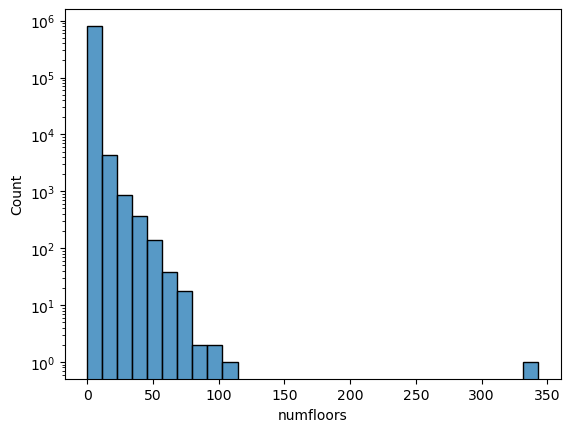

In [20]:
fig, ax = plt.subplots(1, 1)
histplot(x = df['numfloors'], bins = 30, ax = ax)
ax.set_yscale('log')

In [21]:
df.isna().sum()

latitude       1221
longitude      1221
numfloors     42839
unitstotal      495
dtype: int64

In [22]:
df.dropna(subset = ['latitude', 'longitude'], inplace = True)

In [23]:
df.isna().sum()

latitude          0
longitude         0
numfloors     41836
unitstotal      456
dtype: int64

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 857421 entries, 0 to 858641
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   latitude    857421 non-null  float64
 1   longitude   857421 non-null  float64
 2   numfloors   815585 non-null  float64
 3   unitstotal  856965 non-null  float64
dtypes: float64(4)
memory usage: 32.7 MB


In [25]:
np.unique(df['numfloors'].values)

array([  0.  ,   1.  ,   1.01,   1.1 ,   1.15,   1.17,   1.2 ,   1.25,
         1.31,   1.33,   1.35,   1.4 ,   1.5 ,   1.55,   1.6 ,   1.65,
         1.66,   1.67,   1.7 ,   1.75,   1.76,   1.78,   1.8 ,   1.85,
         1.9 ,   1.99,   2.  ,   2.1 ,   2.13,   2.15,   2.2 ,   2.25,
         2.3 ,   2.33,   2.35,   2.37,   2.4 ,   2.45,   2.5 ,   2.55,
         2.6 ,   2.66,   2.67,   2.7 ,   2.75,   2.77,   2.8 ,   2.85,
         2.87,   2.9 ,   2.95,   3.  ,   3.25,   3.3 ,   3.32,   3.33,
         3.4 ,   3.5 ,   3.6 ,   3.67,   3.75,   4.  ,   4.25,   4.27,
         4.28,   4.3 ,   4.33,   4.5 ,   4.66,   4.75,   5.  ,   5.09,
         5.25,   5.5 ,   5.75,   6.  ,   6.21,   6.25,   6.3 ,   6.5 ,
         6.75,   7.  ,   7.25,   7.5 ,   8.  ,   8.5 ,   9.  ,   9.5 ,
        10.  ,  10.5 ,  11.  ,  11.5 ,  12.  ,  12.5 ,  13.  ,  13.5 ,
        14.  ,  14.5 ,  15.  ,  15.5 ,  16.  ,  16.5 ,  17.  ,  18.  ,
        18.5 ,  19.  ,  19.5 ,  20.  ,  20.5 ,  21.  ,  22.  ,  22.5 ,
      

In [28]:
idx_mode = np.argmax(np.unique(df['unitstotal'].values, return_counts = True)[1])

In [33]:
mode = np.unique(df['unitstotal'].values)[idx_mode]

In [36]:
df.fillna(value = {'numfloors': df['numfloors'].dropna().values.mean(), 'unitstotal': mode}, inplace = True)

In [37]:
df.rename(columns={"longitude": "Longitude", "latitude": "Latitude"}, inplace = True)

In [41]:
df.to_csv('../data/initial_datasets/pluto_data.csv', index = False)

##### US Census blocks data

In [3]:
df = pd.read_csv('../data/initial_datasets/us_census_blocks_data.csv')

In [5]:
df = df[['Centroid Longitude', 'Centroid Latitude', 'Decennial Population Count']]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8180866 entries, 0 to 8180865
Data columns (total 3 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Centroid Longitude          float64
 1   Centroid Latitude           float64
 2   Decennial Population Count  int64  
dtypes: float64(2), int64(1)
memory usage: 187.2 MB


In [7]:
df = df[df['Centroid Longitude'] <= -73.86]
df = df[df['Centroid Longitude'] >= -74.01]
df = df[df['Centroid Latitude'] >= 40.75]
df = df[df['Centroid Latitude'] <= 40.88]

In [14]:
df.rename(columns={'Centroid Longitude': "Longitude", 'Centroid Latitude': "Latitude"}, inplace = True)

In [16]:
df.to_csv('../data/initial_datasets/population_count_data.csv', index = False)